# Table of Contents

* [Problem Introduction](#problem-introduction)
    * [Lit Review](#lit-review)
* [Dataset Creation](#dataset-creation)
    * [Process](#process)
    * [runtrack](#runtrack)
* [Model Formulation](#model-formulation)
    * [Description](#description)
    * [Mathematical formulation](#mathematical-formulation)
    * [Code](#code)
* [Instances](#instances)
    * [Graph sizes](#graph-sizes)
    * [Run lengths](#run-lengths)
    * [Generated instances](#generated-instances)
* [Results](#results)
* [Improvements](#improvements)
    * [Interior node removal](#interior-node-removal)
    * [Undirected graph](#undirected-graph)
    * [Failed attempts:](#failed-attempts)
        * [Penalty constraint](#penalty-constraint)
        * [Lower bound](#lower-bound)
        * [Branching](#branching)
* [Conclusion](#conclusion)
* [Declaration of Contribution](#declaration-of-contribution)
* [References](#references)

# Preamble

## Required Packages

The following packages are required for the code to run.

<div class="alert alert-block alert-danger">
<b>To do:</b> Convert back to python
</div

%pip install contextily
%pip install garmin-fit-sdk
%pip install geopandas
%pip install gpxpy
%pip install matplotlib
%pip install networkx
%pip install numpy
%pip install osmnx
%pip install pandas
%pip install requests
%pip install scipy
%pip install seaborn
%pip install shapely
%pip install sklearn

## Imports

In [1]:
import io
import itertools
import math
import os
import pickle
import warnings

from collections import deque
from dataclasses import dataclass

from time import time
from tqdm import tqdm

import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.signal import find_peaks

import pandas as pd
import geopandas as gpd
import shapely as sp
import contextily as cx

import networkx as nx
import osmnx as ox

import requests
from garmin_fit_sdk import Decoder as gfDecoder, Stream as gfStream
import gpxpy

from sklearn.neighbors import BallTree

## Constants & Settings

In [2]:
INSTANCE_DIRECTORY = "instances"

EARTH_RADIUS_M = 6_371_009  # distance in meters
GAR_ANGLE_SCALER = 2**32 / 360

SIGMA_Z = 4.07
BETA = 3

ox.settings.bidirectional_network_types = ["walk", "drive", "all"]
sns.set_theme(style="white")

## Runtrack

The functions and classes in this section are forked from [PyTrack](#pytrack) with substantial changes to make them work for our use case. In brief, the purpose of this module is to match GPS coordinates to OpenStreetMap nodes using a hidden Markov model. We use it to determine the visited count for each edge in our graph.

In [3]:
def graph_to_gdfs(G, nodes=True, edges=True, node_geometry=True, edge_geometry=True):
    """Convert a networkx.MultiDiGraph to node and/or edge pandas DataFrame.

    Parameters
    ----------
    G: networkx.MultiDiGraph
        Street network graph.
    nodes: bool, optional, default: True
        Whether to extract graph nodes.
    edges: bool, optional, default: True
        Whether to extract graph edges.
    node_geometry: bool, optional, default: True
        Whether to compute graph node geometries.
    edge_geometry: bool, optional, default: True
        Whether to extract graph edge geometries.
    Returns
    -------
    gdf_nodes: pandas.DataFrame
        Dataframe collecting graph nodes.
    gdf_edges: pandas.DataFrame
        Dataframe collecting graph edges
    """
    crs = G.graph["crs"]

    if nodes:
        nodes, data = zip(*G.nodes(data=True))

        if node_geometry:
            # convert node x/y attributes to Points for geometry column
            for d in data:
                d["geometry"] = sp.Point(d["x"], d["y"])
            gdf_nodes = pd.DataFrame(data)
            gdf_nodes.insert(loc=0, column="osmid", value=nodes)
        else:
            gdf_nodes = pd.DataFrame(data)
            gdf_nodes.insert(loc=0, column="osmid", value=nodes)

    if edges:
        u, v, data = zip(*G.edges(data=True))
        if edge_geometry:
            G.graph["geometry"] = True

            longs = G.nodes(data="x")
            lats = G.nodes(data="y")

            for d, src, tgt in zip(data, u, v):
                if "geometry" not in d:
                    d["geometry"] = sp.LineString(
                        (
                            sp.Point((longs[src], lats[src])),
                            sp.Point((longs[tgt], lats[tgt])),
                        )
                    )
            gdf_edges = pd.DataFrame(data)

        else:
            gdf_edges = pd.DataFrame(data)
            gdf_edges["geometry"] = None
            gdf_edges.crs = crs

        gdf_edges["u"], gdf_edges["v"] = u, v

        gdf_edges = gdf_edges[["u", "v"] + gdf_edges.columns.to_list()[:-2]]

    if nodes and edges:
        return gdf_nodes, gdf_edges
    elif nodes:
        return gdf_nodes
    elif edges:
        return gdf_edges


def haversine_dist(lat1, lon1, lat2, lon2):
    """Calculate the great circle distance between two points on the earth (specified in decimal degrees)

    Parameters
    ----------
    lat1: float
        Latitude of the first point specified in decimal degrees
    lon1: float
        Longitude of the first point specified in decimal degrees
    lat2: float
        Latitude of the second point specified in decimal degrees
    lon2: float
        Longitude of the second point specified in decimal degrees

    earth_radius: float, optional, default: 6371009.0 meters
        Earth's radius
    Returns
    ----------
    dist: float
        Distance in units of earth_radius
    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.deg2rad, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # haversine formula
    h = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    h = np.minimum(1, h)  # protect against floating point errors
    arc = 2 * np.arcsin(np.sqrt(h))

    dist = arc * EARTH_RADIUS_M

    return dist


In [4]:
@dataclass
class Candidate:
    node_id: str
    edge_osmid: str
    obs: tuple
    great_dist: float
    coord: tuple


class CandidateHandler:
    __slots__ = ["ball_tree", "coords", "G", "index", "nodes", "nodes_deg", "rtree"]

    def __init__(self, G):
        self.G = G
        geoms = graph_to_gdfs(self.G, nodes=False).set_index(["u", "v"])[
            ["osmid", "geometry"]
        ]

        uv_xy = [
            [u, osmid, np.deg2rad(xy)]
            for uv, geom, osmid in zip(
                geoms.index, geoms.geometry.values, geoms.osmid.values
            )
            for u, xy in zip(uv, geom.coords[:])
        ]

        index, osmid, xy = zip(*uv_xy)
        self.index = np.array(index)

        x, y = zip(*xy)
        self.nodes = gpd.GeoSeries.from_xy(x, y, index=osmid)
        self.nodes_deg = self.nodes.apply(lambda x: sp.transform(x, np.rad2deg))
        self.rtree = self.nodes_deg.sindex
        self.coords = self.nodes.get_coordinates()

        self.ball_tree = BallTree(self.coords, metric="haversine")

        # return index, nodes, nodes_deg, rtree, coords, ball

    def get_candidates(self, df, radius=10):
        """Extract candidate points for Hidden-Markov Model map-matching approach.

        Parameters
        ----------
        G: networkx.MultiDiGraph
            Street network graph.
        points: list
            The actual GPS points.
        interp_dist: float, optional, default: 1
            Step to interpolate the graph. The smaller the interp_dist, the greater the precision and the longer
            the computational time.
        closest: bool, optional, default: True
            If true, only the closest point is considered for each edge.
        radius: float, optional, default: 10
            Radius of the search circle.
        Returns
        -------
        G: networkx.MultiDiGraph
            Street network graph.
        results: dict
            Results to be used for the map-matching algorithm.
        """
        points = [
            (lng, lat)
            for lat, lng in zip(
                df["position_lat"].to_list(), df["position_long"].to_list()
            )
        ]
        idxs, dists = self.ball_tree.query_radius(
            np.deg2rad(points), radius / EARTH_RADIUS_M, return_distance=True
        )
        not_found = [
            [points[i], i] for i, idx_array in enumerate(idxs) if idx_array.size == 0
        ]
        while len(not_found) > 0:
            not_found, nf_i = zip(*not_found)
            radius = radius * 2
            nf_idxs, nf_dists = self.ball_tree.query_radius(
                np.deg2rad(not_found), radius / EARTH_RADIUS_M, return_distance=True
            )
            idxs[list(nf_i)] = nf_idxs
            dists[list(nf_i)] = nf_dists
            not_found = [
                [points[i], i]
                for i, idx_array in enumerate(idxs)
                if idx_array.size == 0
            ]

        dists = dists * EARTH_RADIUS_M  # radians to meters

        results = {
            i: {
                "observation": point,
                "osmid": list(self.index[idx]),
                "edge_osmid": list(self.nodes.index[idx]),
                "candidates": list(map(tuple, np.rad2deg(self.coords.values[idx]))),
                "candidate_type": np.full(len(self.nodes.index[idx]), False),
                "dists": list(dist),
            }
            for i, (point, idx, dist) in enumerate(zip(points, idxs, dists))
        }

        no_cands = [
            node_id for node_id, cand in results.items() if not cand["candidates"]
        ]

        if no_cands:
            for cand in no_cands:
                del results[cand]
            print(
                f"A total of {len(no_cands)} points have no candidates.",
                end=" ",
                flush=True,
            )

        dist = max(
            max(results.values(), key=lambda point: max(point["dists"]))["dists"]
        )  # max distance
        gdf = gpd.GeoDataFrame(
            geometry=[
                sp.MultiPoint(
                    [
                        latlng
                        for point in results.values()
                        for latlng in point["candidates"]
                    ]
                ).convex_hull
            ],
            crs="EPSG:4326",
        )
        gdf = gdf.to_crs(gdf.estimate_utm_crs())
        gdf.geometry.buffer(max(dist * 10, 500))
        gdf = gdf.to_crs("EPSG:4326")

        possible_matches_iloc = self.rtree.query(
            gdf.geometry[0], predicate="intersects"
        )
        possible_matches = self.nodes_deg.iloc[list(possible_matches_iloc)]

        precise_matches = possible_matches[possible_matches.intersects(gdf.geometry[0])]
        to_keep = set(precise_matches.index)

        try:
            to_remove = set(self.index[~self.nodes_deg.index.isin(to_keep)])
            to_keep = set(self.index[self.nodes_deg.index.isin(to_keep)])
        except NameError as err:
            raise ValueError(
                "Found no graph nodes within the requested polygon."
            ) from err

        if len(to_keep) < len(to_remove):
            G_sub = self.G.subgraph(to_keep).copy()
        else:
            G_sub = self.G.copy().remove_nodes_from(to_remove)

        return G_sub, results, len(to_remove) / len(self.G.nodes)

In [5]:
class Matcher:
    __slots__ = [
        "candidates",
        "G",
        "joint_probs",
        "known_dists",
        "predecessors",
        "trellis",
    ]

    def __init__(self, G, candidates, known_dists):
        self.G = G
        self.candidates = candidates
        self.known_dists = known_dists

    @staticmethod
    def get_predecessor(target, predecessor):
        """Reconstruct predecessor dictionary of a decoded trellis DAG.

        Parameters
        ----------
        target: str
            Target node of the trellis DAG.
        predecessor: dict
            Dictionary containing the predecessors of the nodes of a decoded Trellis DAG.
        Returns
        -------
        pred_elab: dict
            Dictionary containing the predecessors of the best nodes of a decoded Trellis DAG.
        """
        pred_elab = {}
        pred = predecessor[target]
        while pred != "start":
            if target.startswith("gap"):
                pred_elab[target] = pred
            else:
                pred_elab[target.split("_")[0]] = pred
            target = pred
            pred = predecessor[target]
        return pred_elab

    # A gaussian distribution
    @staticmethod
    def emission_prob(u, sigma=SIGMA_Z):
        """Compute emission probability of a node

        Parameters
        ----------
        u: runtrack.matching.Candidate
            Node of the graph.
        sigma: float, optional, default: SIGMA_Z
            It is an estimate of the magnitude of the GPS error. See https://www.ismll.uni-hildesheim.de/lehre/semSpatial-10s/script/6.pdf
            for a more detailed description of its calculation.

        Returns
        -------
        ret: float
            Emission probability of a node.
        """
        if u.great_dist:
            c = 1 / (sigma * math.sqrt(2 * math.pi))
            return c * math.exp(-((u.great_dist / sigma) ** 2))
        else:
            return 1

    # A empirical distribution
    def transition_prob(self, u, v, beta=BETA):
        """Compute transition probability between node u and v.

        Parameters
        ----------
        G: networkx.MultiDiGraph
            Road network graph.
        u: dict
            Starting node of the graph.
        v: dict
            Target node of the graph.
        beta: float
            This describes the difference between route distances and great circle distances. See https://www.ismll.uni-hildesheim.de/lehre/semSpatial-10s/script/6.pdf
            for a more detailed description of its calculation.

        Returns
        -------
        ret: float
            Transition probability between node u and v.
        """
        c = 1 / beta

        if u.great_dist and v.great_dist:
            s = u if u.node_id < v.node_id else v
            t = u if u.node_id > v.node_id else v
            if (
                s.node_id not in self.known_dists
                or t.node_id not in self.known_dists[s.node_id]
            ):
                weight = nx.algorithms.shortest_paths.weighted._weight_function(
                    self.G, "length"
                )
                paths = {s.node_id: [s.node_id]}
                sp_dist = nx.algorithms.shortest_paths.weighted._dijkstra(
                    self.G, s.node_id, weight, paths=paths, target=t.node_id
                )
                if s.node_id not in self.known_dists:
                    self.known_dists[s.node_id] = {}
                for target, path in reversed(paths.items()):
                    if target not in sp_dist:
                        sp_dist[target] = sum(
                            weight(path[i], path[i + 1], self.G[path[i]][path[i + 1]])
                            for i in range(len(path) - 1)
                        )
                    for idx, pred in enumerate(path):
                        if pred not in sp_dist:
                            sp_dist[pred] = path[idx - 1] + weight(
                                path[idx - 1], pred, self.G[path[idx - 1]][pred]
                            )
                        s_path = pred if pred < target else target
                        t_path = pred if pred > target else target
                        if s_path not in self.known_dists:
                            self.known_dists[s_path] = {}
                        if t_path not in self.known_dists[s_path]:
                            self.known_dists[s_path][t_path] = {
                                "shortest_path": sp_dist[target] - sp_dist[pred]
                            }
                        else:
                            break
                try:
                    self.known_dists[s.node_id][t.node_id]
                except KeyError:
                    for pred in sp_dist.keys():
                        if pred < t.node_id:
                            self.known_dists[pred][t.node_id] = None
                        else:
                            self.known_dists[t.node_id][pred] = None

            try:
                if "haversine_dist" not in self.known_dists[s.node_id][t.node_id]:
                    self.known_dists[s.node_id][t.node_id]["haversine_dist"] = (
                        haversine_dist(*u.coord, *v.coord)
                    )
                delta = abs(
                    self.known_dists[s.node_id][t.node_id]["shortest_path"]
                    - self.known_dists[s.node_id][t.node_id]["haversine_dist"]
                )
            except TypeError as err:
                raise nx.NetworkXNoPath(f"No path to {v.node_id}.") from err
            return c * math.exp(-delta / beta)
        else:
            return 1

    def create_trellis(self, tq):
        self.trellis = nx.DiGraph()

        prev_nodes = ["start"]
        self.trellis.add_node(
            "start", candidate=Candidate("start", None, None, None, None)
        )
        self.trellis.add_node(
            "target", candidate=Candidate("start", None, None, None, None)
        )

        for idx, item in self.candidates.items():
            obs = item["observation"]
            nodes, data_node = zip(
                *[
                    (
                        f"{idx}_{j}",
                        {"candidate": Candidate(node_id, edge_osmid, obs, dist, cand)},
                    )
                    for j, (node_id, edge_osmid, dist, cand) in enumerate(
                        zip(
                            item["osmid"],
                            item["edge_osmid"],
                            item["dists"],
                            item["candidates"],
                        )
                    )
                ]
            )
            edges = [(u, v) for u in prev_nodes for v in nodes]

            self.trellis.add_nodes_from(zip(nodes, data_node))
            self.trellis.add_edges_from(edges)
            prev_nodes = nodes
            tq.update(0.15 / len(self.candidates))

        edges = [(u, "target") for u in prev_nodes]
        self.trellis.add_edges_from(edges)

    def viterbi_search(
        self, tq, start="start", target="target", sigma=SIGMA_Z, beta=BETA
    ):
        """Function to compute viterbi search and perform Hidden-Markov Model map-matching.

        Parameters
        ----------
        G: networkx.MultiDiGraph
            Street network graph.
        trellis:
        start: str, optional, default: "start"
            Starting node.
        target: str, optional, default: "target"
            Target node.
        beta: float
            This describes the difference between route distances and great circle distances. See https://www.ismll.uni-hildesheim.de/lehre/semSpatial-10s/script/6.pdf
            for a more detailed description of its calculation.

        sigma: float
            It is an estimate of the magnitude of the GPS error. See https://www.ismll.uni-hildesheim.de/lehre/semSpatial-10s/script/6.pdf
            for a more detailed description of its calculation.

        Returns
        -------
        joint_prob: dict
            Joint probability for each node.
        predecessor: dict
            Predecessor for each node.

        Notes
        -----
        See https://www.ismll.uni-hildesheim.de/lehre/semSpatial-10s/script/6.pdf for a more detailed description of this
        method.
        """

        # Initialize joint probability for each node
        joint_prob = {}
        for u_name in self.trellis.nodes():
            joint_prob[u_name] = -float("inf")
        predecessor = {}
        predecessor_val = {}

        queue = deque()
        queue.append(start)
        joint_prob[start] = math.log10(
            self.emission_prob(self.trellis.nodes[start]["candidate"], sigma)
        )
        predecessor[start] = None
        gaps = 0

        while queue:
            # Extract node u
            u_name = queue.popleft()
            u = self.trellis.nodes[u_name]["candidate"]
            if u_name == target:
                break
            for v_name in list(self.trellis.successors(u_name)):
                v = self.trellis.nodes[v_name]["candidate"]

                try:
                    new_prob = (
                        joint_prob[u_name]
                        + math.log10(self.emission_prob(v, sigma))
                        + math.log10(self.transition_prob(u, v, beta))
                    )

                    if joint_prob[v_name] < new_prob:
                        joint_prob[v_name] = new_prob
                        if v_name not in predecessor:
                            predecessor[v_name] = u_name
                            predecessor_val[v_name] = new_prob
                        elif (
                            v_name in predecessor and predecessor_val[v_name] < new_prob
                        ):
                            predecessor[v_name] = u_name
                            predecessor_val[v_name] = new_prob
                    if v_name not in queue:
                        queue.append(v_name)

                except Exception:
                    pass

            if not queue:
                if u_name.startswith("gap") or u_name == "start":
                    for v_succ in self.trellis.successors(v_name):
                        self.trellis.add_edge(u_name, v_succ)
                    queue.append(u_name)
                    tq.update(-0.7 / nx.number_of_nodes(self.trellis))
                    continue
                self.trellis.add_node(
                    f"gap_{gaps}", candidate=Candidate("start", None, None, None, None)
                )
                joint_prob[f"gap_{gaps}"] = -float("inf")
                for v_sib in self.trellis.successors(u_name):
                    self.trellis.add_edge(f"gap_{gaps}", v_sib)
                for u_sib in self.trellis.successors(predecessor[u_name]):
                    self.trellis.add_edge(u_sib, f"gap_{gaps}")
                    if u_sib in predecessor.keys():
                        queue.append(u_sib)
                        tq.update(-0.7 / nx.number_of_nodes(self.trellis))
                gaps = gaps + 1

            tq.update(0.7 / nx.number_of_nodes(self.trellis))

        self.predecessors = self.get_predecessor("target", predecessor)
        self.joint_probs = joint_prob

        return gaps

    def create_path(self, G, tq):
        """Create the path that best matches the actual GPS data.

        Parameters
        ----------
        G: networkx.MultiDiGraph
            Road network graph.
        trellis: networkx.DiGraph
            A directed acyclic graph.
        predecessor: dict
            Predecessor for each node.
        Returns
        -------
        path_elab: list
            List of node IDs.
        """
        u, v = list(zip(*[(u, v) for v, u in self.predecessors.items()][::-1]))
        path = [(u, v) for u, v in zip(u, u[1:])]
        path_elabs = []
        path_elab = []
        isolates = set()

        for u, v in path:
            if u.startswith("gap"):
                continue
            if v.startswith("gap"):
                if path_elab:
                    path_elabs.append(path_elab)
                    path_elab = []
                else:
                    isolates.add(self.trellis.nodes[u]["candidate"].node_id)
                continue

            path_elab.extend(
                nx.shortest_path(
                    G,
                    self.trellis.nodes[u]["candidate"].node_id,
                    self.trellis.nodes[v]["candidate"].node_id,
                    weight="length",
                )
            )
        path_elabs.append(path_elab)
        tq.update(0.025 / len(path))
        for idx, path_elab in enumerate(path_elabs):
            path_elabs[idx] = [k for k, g in itertools.groupby(path_elab)]
            if len(path_elab) == 1:
                isolates.add(path_elab[0])
            tq.update(0.025 / len(path_elabs))
        path_elabs = [path_elab for path_elab in path_elabs if len(path_elab) > 1]
        return path_elabs, len(isolates)


# Problem Introduction

Running long distances is the kind of hobby where monotony can set in for even its most ardent devotees, particularly in urban areas where there may not be much in the way of scenery. In an effort to mitigate potential boredom, many runners seek out new routes, which has become a hobby in itself with apps like [CityStrides](#citystrides) and [Wandrer](#wandrer).

## Literature Review

# Dataset Creation

The `filter` string is made publicly available by CityStrides via a [Google Sheet](https://docs.google.com/spreadsheets/d/1dbj5giwBhCG-jWmokCnQOJhkIEE132FvXVyrvDL7tSU/) as documented in their [Wiki](https://community.citystrides.com/t/osm-basics/21283).

In [ ]:
class InstanceHandler:
    __slots__ = [
        "data_dir",
        "dir",
        "C",
        "G",
        "gdf",
        "instances",
        "name",
        "place",
        "plot_data",
        "routes",
    ]
    filter = (
        "['name']['highway']['highway' !~ 'bridleway']['highway' !~ 'bus_guideway']"
        "['highway' !~ 'bus_stop']['highway' !~ 'busway']['highway' !~ 'construction']"
        "['highway' !~ 'corridor']['highway' !~ 'cycleway']['highway' !~ 'elevator']"
        "['highway' !~ 'escape']['highway' !~ 'footway']['highway' !~ 'motorway']"
        "['highway' !~ 'motorway_junction']['highway' !~ 'motorway_link']"
        "['highway' !~ 'path']['highway' !~ 'platform']['highway' !~ 'proposed']"
        "['highway' !~ 'raceway']['highway' !~ 'razed']['highway' !~ 'rest_area']"
        "['highway' !~ 'services']['highway' !~ 'steps']['highway' !~ 'track']"
        "['highway' !~ 'trunk']['access' !~ 'customers']['access' !~ '^(no)$']"
        "['access' !~ 'private']['aeroway' !~ 'jet_bridge']['amenity' !~ 'theatre']"
        "['amenity' !~ 'weighbridge']['area' !~ 'yes']['expressway' !~ 'yes']"
        "['fee' !~ 'yes']['foot' !~ 'no']['indoor' !~ 'area']['indoor' !~ 'column']"
        "['indoor' !~ 'corridor']['indoor' !~ 'door']['indoor' !~ 'level']"
        "['indoor' !~ 'room']['indoor' !~ 'wall']['indoor' !~ 'yes']['motorroad' !~ 'yes']"
        "['public_transport' !~ 'platform']['road' !~ 'highway']['service' !~ 'drive-through']"
        "['service' !~ 'driveway']['service' !~ 'parking_aisle']['toll' !~ 'yes']"
    )
    github_url = (
        "https://raw.githubusercontent.com/jingng/MIE1603-Project/refs/heads/main"
    )
    instances_dir = INSTANCE_DIRECTORY

    def __init__(self, place, instance_name, load_from_files=False):
        self.place = place
        self.name = instance_name
        self.dir = f"{INSTANCE_DIRECTORY}/{self.name}"
        self.instances = {}
        self.plot_data = {}

        if load_from_files and os.path.isdir(self.dir):
            for attribute in self.__slots__:
                filename = f"{self.dir}/{attribute}.pkl"
                if os.path.isfile(filename):
                    with open(filename, "rb") as file:
                        setattr(self, attribute, pickle.load(file))
            for instance_type in ["base", "noderem"]:
                filename = f"{self.dir}/{instance_type}.pkl"
                if os.path.isfile(filename):
                    with open(filename, "rb") as file:
                        self.instances[instance_type] = pickle.load(file)

    # static methods

    @staticmethod
    def convert_nodes_to_gdf(G):
        node_geometry = []
        node_data = []

        for _, data in G.nodes(data=True):
            # Extract x and y coordinates from node data
            x = data.get("x")
            y = data.get("y")

            if x is not None and y is not None:
                node_geometry.append(sp.Point(x, y))
                node_data.append(data)
        gdf = gpd.GeoDataFrame(node_data, geometry=node_geometry, crs="EPSG:4326")

        return gdf

    @staticmethod
    def convert_edges_to_gdf(G):
        edge_geometry = []
        edge_data = []

        for u, v, data in G.edges(data=True):
            if "geometry" in data:
                geometry = data["geometry"]
            else:
                # If no geometry is explicitly provided, create a LineString from node coordinates
                u_data = G.nodes[u]
                v_data = G.nodes[v]
                u_point = (u_data["x"], u_data["y"])
                v_point = (v_data["x"], v_data["y"])
                geometry = sp.LineString([u_point, v_point])

            edge_geometry.append(geometry)
            edge_data.append(data)

        gdf = gpd.GeoDataFrame(edge_data, geometry=edge_geometry, crs="EPSG:4326")

        return gdf

    @staticmethod
    def start_timer(name=None):
        if name is not None:
            print(name, end=" ", flush=True)
        return time()

    @staticmethod
    def end_timer(st, status=None):
        if status is None:
            status = ""
        if time() - st < 60:
            print(status + f" - {time() - st:.1f} s")
        else:
            print(status + f"- {(time() - st) / 60:.1f} m")

    @staticmethod
    def penalty_function(v_max, ub, mid, scale):
        if ub <= 1:
            return lambda v_count: ub

        b = (1 - ub) / (
            (1 - mid) / np.sqrt((1 - mid) ** 2 + scale**2)
            - (v_max - mid) / np.sqrt((v_max - mid) ** 2 + scale**2)
        )
        a = 1 - b * (1 - mid) / np.sqrt((1 - mid) ** 2 + scale**2)

        def penalty(v_count):
            y = a + b * (v_count - mid) / np.sqrt((v_count - mid) ** 2 + scale**2)
            return y

        return penalty

    @staticmethod
    def lighten_and_truncate_cmap(cmap, minval=0, maxval=1):
        return mcolors.LinearSegmentedColormap.from_list(
            "subset",
            [
                (r, g, b, a)
                for a, (r, g, b, _) in [
                    (x, cmap(x)) for x in np.linspace(minval, maxval, cmap.N)
                ]
            ],
        )

    @staticmethod
    def create_cbar(fig, ax, cmap, norm):
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        # Add the horizontal colorbar
        cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
        fig_width, fig_height = fig.get_size_inches()
        cbar.ax.set_xlabel("Number of traversals", size=round(fig_height * 2))
        cbar.ax.xaxis.set_ticks_position("none")  # Disables ticks
        label_positions = [1, math.floor(norm.vmax / 25) * 25]
        cbar.ax.set_xticks(label_positions)  # Set positions explicitly
        cbar.ax.set_xticklabels(
            [f"{int(x)}" for x in label_positions]
        )  # Format labels as integers
        cbar.ax.tick_params(labelsize=round(fig_height * 2))

    # instance methods
    def in_bbox(self, lat, lng):
        return (
            lat.between(
                self.gdf.loc[0, "bbox_south"], self.gdf.loc[0, "bbox_north"]
            ).any()
            and lng.between(
                self.gdf.loc[0, "bbox_west"], self.gdf.loc[0, "bbox_east"]
            ).any()
        )

    def intersects_G(self, gdf):
        return gdf.geometry.intersects(self.gdf.geometry.loc[0]).any()

    def plot(self, plot_type="G"):
        if plot_type == "G":
            node_gdf = self.convert_nodes_to_gdf(self.G)
            edge_gdf = self.convert_edges_to_gdf(self.G)
            node_color = cm.Paired.colors[9]
            edge_color = cm.Paired.colors[8]
        elif plot_type == "C":
            node_gdf = self.convert_nodes_to_gdf(self.C)
            edge_gdf = self.convert_edges_to_gdf(self.C)
            node_color = cm.Paired.colors[1]
            edge_color = cm.Paired.colors[0]
        elif plot_type == "removed":
            node_gdf = self.convert_nodes_to_gdf(self.instances["noderem"])
            edge_gdf = self.convert_edges_to_gdf(self.instances["noderem"])
            node_color = cm.Paired.colors[1]
            edge_color = cm.Paired.colors[0]
        elif plot_type == "heatmap":
            node_gdf = self.convert_nodes_to_gdf(self.G)
            edge_gdf = self.convert_edges_to_gdf(self.C)
            if "visited" not in edge_gdf.columns:
                print("No visited counts, can't plot heatmap.")
                return
            edge_gdf.geometry = edge_gdf.geometry.normalize()
            edge_gdf = gpd.GeoDataFrame(
                edge_gdf.groupby(["geometry"], as_index=False)["visited"].sum(),
                geometry="geometry",
                crs="EPSG:4326",
            )
            norm = mcolors.LogNorm(vmin=1, vmax=edge_gdf.visited.max())
            cmap = self.lighten_and_truncate_cmap(cm.turbo, 0.4, 1)
        elif plot_type.startswith("profit") or plot_type.startswith("penalty"):
            try:
                plot_data = self.plot_data[plot_type.split("_")[1]]
                edge_gdf = self.convert_edges_to_gdf(
                    self.instances[plot_type.split("_")[1]]
                )
                fig, ax = plt.subplots(3, 1, figsize=(5, 12), dpi=300)
                ax[0].set_yscale("log")
                sns.despine(fig)
                sns.histplot(
                    edge_gdf[edge_gdf.visited > 0],
                    x="visited",
                    bins=50,
                    ax=ax[0],
                )
                ax[1].set_xscale("log")
                ax[1].set_yscale("log")
                sns.scatterplot(plot_data["vc"], x="visited", y="edges", ax=ax[1])
                plt.tight_layout()

                ax[2].set(
                    ylim=(
                        0,
                        max(
                            min(
                                plot_data["curve"]["c"].max(),
                                plot_data["curve"]["s"].max(),
                            )
                            * 1.5,
                            np.percentile(plot_data["vc"]["edges"], 75),
                        ),
                    )
                )
                sns.scatterplot(
                    plot_data["vc"][["edges", "peaks"]].set_index(
                        plot_data["vc"]["visited"]
                    ),
                    palette="flare_r",
                    ax=ax[2],
                )
                sns.lineplot(plot_data["curve"], palette="crest", ax=ax[2])
                sns.move_legend(ax[2], loc="upper right", ncol=2)
                plt.show()
                return

            except AttributeError:
                print("No profit or penalty data available.")
                return
            except IndexError:
                print("Instance type not specified. Use <profit>_<type> to plot.")
                return
            except KeyError:
                print(f"No data for instance type {plot_type.split('_')[1]} found.")
                return

        # do this for all
        minx, miny, maxx, maxy = node_gdf.to_crs(
            node_gdf.estimate_utm_crs()
        ).total_bounds
        print(
            math.ceil((maxx - minx) / 1000),
            math.ceil((maxy - miny) / 1000),
        )
        fig, ax = plt.subplots(
            figsize=(
                math.ceil((maxx - minx) / 1000),
                math.ceil((maxy - miny) / 1000),
            ),
            dpi=300,
        )

        if plot_type == "heatmap":
            node_gdf.to_crs(epsg=3857).plot(ax=ax, alpha=0)
            lims = {"x": plt.gca().get_xlim(), "y": plt.gca().get_ylim()}
            edge_gdf.to_crs(epsg=3857).plot(
                ax=ax, column="visited", cmap=cmap, norm=norm, legend=False
            )
            self.create_cbar(fig, ax, cmap, norm)
            ax.set_xlim(lims["x"])
            ax.set_ylim(lims["y"])
        else:
            node_gdf.to_crs(epsg=3857).plot(
                ax=ax, color=node_color, markersize=1, zorder=4
            )
            edge_gdf.to_crs(epsg=3857).plot(ax=ax, color=edge_color, zorder=2)
        cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager, attribution_size=1)
        ax.axis("off")
        plt.show()

    def save_to_file(self, attribute, name=None):
        os.makedirs(self.dir, exist_ok=True)
        if name:
            with open(f"{self.dir}/{name}.pkl", "wb") as file:
                pickle.dump(attribute, file, pickle.HIGHEST_PROTOCOL)
        else:
            for name in self.__slots__:
                if hasattr(self, name) and getattr(self, name) is attribute:
                    with open(f"{self.dir}/{name}.pkl", "wb") as file:
                        pickle.dump(attribute, file, pickle.HIGHEST_PROTOCOL)

    def create_cs_graph(self):
        st = self.start_timer("Creating citystrides graph")

        ox.settings.bidirectional_network_types = ["walk", "drive", "all"]

        # Sunshine Hills is not available as a relation on OSM, have to build our own
        if self.place == "Sunshine Hills":
            polygon = sp.Polygon(
                (
                    (-122.9186029, 49.1339211),
                    (-122.9182107, 49.1339005),
                    (-122.9173290, 49.1339171),
                    (-122.9103271, 49.1339019),
                    (-122.9035110, 49.1339256),
                    (-122.8936911, 49.1340445),
                    (-122.8936357, 49.1303340),
                    (-122.8903685, 49.1303445),
                    (-122.8903126, 49.1193827),
                    (-122.8977329, 49.1194226),
                    (-122.9002307, 49.1190351),
                    (-122.9042114, 49.1190365),
                    (-122.9076843, 49.1188845),
                    (-122.9154025, 49.1187948),
                    (-122.9159985, 49.1188319),
                    (-122.9176966, 49.1191495),
                    (-122.9182936, 49.1176611),
                    (-122.9218904, 49.1175943),
                    (-122.9219042, 49.1190088),
                    (-122.9233853, 49.1189902),
                    (-122.9236629, 49.1229190),
                    (-122.9209377, 49.1276241),
                )
            )
            G = ox.graph.graph_from_polygon(
                sp.make_valid(polygon),
                retain_all=True,
                truncate_by_edge=True,
                custom_filter=self.filter,
                simplify=False,
            )
            gdf = {
                "geometry": [polygon],
                "bbox_west": [
                    G.nodes[min(G.nodes, key=lambda node: G.nodes[node]["x"])]["x"]
                ],
                "bbox_south": [
                    G.nodes[min(G.nodes, key=lambda node: G.nodes[node]["y"])]["y"]
                ],
                "bbox_east": [
                    G.nodes[max(G.nodes, key=lambda node: G.nodes[node]["x"])]["x"]
                ],
                "bbox_north": [
                    G.nodes[max(G.nodes, key=lambda node: G.nodes[node]["y"])]["y"]
                ],
            }
            gdf = gpd.GeoDataFrame(gdf, crs="EPSG:4326")
        else:
            G = ox.graph.graph_from_place(
                self.place,
                retain_all=True,
                truncate_by_edge=True,
                custom_filter=self.filter,
                simplify=False,
            )
            gdf = ox.geocoder.geocode_to_gdf(self.place)

        self.G = nx.DiGraph(G)
        self.gdf = gdf

        self.save_to_file(self.G)
        self.save_to_file(self.gdf)

        self.end_timer(st)

    def create_routes(self):
        st = self.start_timer()
        activities_df = pd.read_csv(
            f"{self.github_url}/strava_data_{self.name.split('-')[0]}/activities.csv",
            index_col=0,
        )
        activities_df = activities_df[
            activities_df["Activity Type"].isin(["Run", "Walk"])
        ]

        routes = {}
        fit_cnt = 0
        gpx_cnt = 0
        for i, row in tqdm(
            activities_df.iterrows(),
            total=activities_df.shape[0],
            leave=False,
            desc="\rCreating list of routes: ",
        ):
            filename = (
                f"{self.github_url}/strava_data_{self.name.split('-')[0]}/"
                + row["Filename"]
            )
            if filename[-3:] == ".gz":
                filename = filename[:-3]
            response = requests.get(filename)
            if response.status_code == 200:
                # handle .fit files
                if filename[-3:] == "fit":
                    fit_cnt = fit_cnt + 1
                    stream = gfStream.from_bytes_io(io.BytesIO(response.content))
                    decoder = gfDecoder(stream)
                    messages, _ = decoder.read(convert_datetimes_to_dates=True)
                    try:
                        record = messages["record_mesgs"]
                    except KeyError:
                        # no record messages
                        continue
                    df = pd.DataFrame(record)
                    try:
                        df = df.set_index("timestamp")[
                            ["position_lat", "position_long"]
                        ]
                    except KeyError:
                        # no position data
                        continue
                # handle .gpx files
                elif filename[-3:] == "gpx":
                    gpx_cnt = gpx_cnt + 1
                    gpx = gpxpy.parse(response.text)

                    points = []
                    for segment in gpx.tracks[0].segments:
                        for point in segment.points:
                            points.append(
                                {
                                    "timestamp": point.time,
                                    "position_lat": point.latitude,
                                    "position_long": point.longitude,
                                }
                            )
                    df = pd.DataFrame.from_records(points)
                    df = df.set_index("timestamp")
                else:
                    continue
                # handle garmin angle scaling
                if df["position_lat"].max() > 90:
                    df = df / GAR_ANGLE_SCALER
                if self.in_bbox(df["position_lat"], df["position_long"]):
                    df = df.dropna(axis="index", how="any")
                    gdf = gpd.GeoDataFrame(
                        df,
                        geometry=gpd.points_from_xy(df.position_long, df.position_lat),
                        crs="EPSG:4326",
                    )
                    if self.intersects_G(gdf):
                        routes[i] = gdf.tz_convert(None)

        self.routes = routes
        self.save_to_file(self.routes)
        self.end_timer(
            st,
            f"\rCreating list of routes: {fit_cnt} .fit and {gpx_cnt} .gpx files processed, {len(routes)} valid routes found.",
        )

    def create_composite_graph(self):
        st = self.start_timer("Creating route graphs")
        ch_gdf = gpd.GeoDataFrame(
            geometry=[
                self.convert_nodes_to_gdf(self.G).geometry.union_all().convex_hull
            ],
            crs="EPSG:4326",
        )
        ch_gdf = ch_gdf.to_crs(ch_gdf.estimate_utm_crs())
        ch_gdf.geometry = ch_gdf.geometry.buffer(500)
        ch_gdf = ch_gdf.to_crs("EPSG:4326")

        route_gdf = None
        for gdf in self.routes.values():
            if route_gdf is None:
                route_gdf = gdf
            else:
                route_gdf = pd.concat([route_gdf, gdf])
        precision = (
            min(
                abs(self.gdf.loc[0, "bbox_west"] - self.gdf.loc[0, "bbox_east"]),
                abs(self.gdf.loc[0, "bbox_south"] - self.gdf.loc[0, "bbox_north"]),
            )
            / 10
        )
        buffer = (
            min(
                abs(self.gdf.loc[0, "bbox_west"] - self.gdf.loc[0, "bbox_east"]),
                abs(self.gdf.loc[0, "bbox_south"] - self.gdf.loc[0, "bbox_north"]),
            )
            / 8
        )
        route_gdf.geometry = sp.set_precision(
            route_gdf.geometry,
            precision,
        )
        route_gdf = gpd.GeoDataFrame(
            geometry=[
                route_gdf.drop_duplicates(subset=["geometry"]).geometry.union_all()
            ],
            crs="EPSG:4326",
        )
        with warnings.catch_warnings(action="ignore"):
            route_gdf.geometry = route_gdf.geometry.buffer(buffer).union(
                ch_gdf.geometry
            )

        H_runnable = ox.graph_from_polygon(
            route_gdf.geometry.loc[0],
            network_type="walk",
            retain_all=True,
            truncate_by_edge=True,
            simplify=False,
        )
        H_citystrides = ox.graph_from_polygon(
            route_gdf.geometry.loc[0],
            network_type="all",
            retain_all=True,
            truncate_by_edge=True,
            simplify=False,
            custom_filter=self.filter,
        )
        self.end_timer(st)
        self.start_timer("Creating composite graph")
        C = nx.compose(
            self.G, nx.compose(nx.DiGraph(H_runnable), nx.DiGraph(H_citystrides))
        )
        self.C = C
        self.save_to_file(self.C)

        self.end_timer(st)

    def add_visited_counts(self):
        st = self.start_timer("Preparing candidate nodes")
        nx.set_edge_attributes(self.C, 0, "visited")
        ch = CandidateHandler(self.C)
        self.end_timer(st)
        known_dists = {}
        gaps = 0
        isolates = 0
        st = self.start_timer()
        tq = tqdm(
            total=len(self.routes),
            desc="Matching routes to OSM",
            unit="rt",
            leave=False,
            bar_format="{l_bar}{bar}| {n:.1f}/{total:.0f} [{elapsed}, {rate_fmt}{postfix}]",
        )
        for id, df in self.routes.items():
            C_sub, candidate_matches, reduced = ch.get_candidates(df)
            tq.update(0.1)

            matcher = Matcher(C_sub, candidate_matches, known_dists)
            matcher.create_trellis(tq=tq)
            gaps = gaps + matcher.viterbi_search(tq=tq)
            paths, isolates = matcher.create_path(self.C, tq=tq)

            for path in paths:
                for u, v in zip(path, path[1:]):
                    nx.set_edge_attributes(
                        self.C, {(u, v): {"visited": self.C[u][v]["visited"] + 1}}
                    )
        self.save_to_file(self.C)
        tq.close()
        self.end_timer(
            st,
            f"Matching routes to OSM: {gaps} gaps across all routes, {isolates} unreachable nodes removed.",
        )

    def add_profit_penalty(self, C_inst):
        st = self.start_timer("Calculating profit and penalty")
        R = C_inst.edge_subgraph(
            (edge[:2] for edge in C_inst.edges(data="visited") if int(edge[2]) > 0)
        ).copy()
        R_G = R.copy()
        R_G.remove_nodes_from(n for n in R if n not in self.G)
        R_G.remove_edges_from(e for e in R.edges if e not in self.G.edges)

        df = nx.to_pandas_edgelist(R_G)
        vc = df["visited"].value_counts().rename("edges").to_frame().reset_index()
        vc = vc.sort_values(by=["visited"])
        vc = vc.reset_index(drop=True)

        r = R_G.size("length") / self.G.size("length")
        s = max(r / (1 - r) * vc["visited"].max(), 1)
        c = min(s, vc["visited"].max()) * (1 - r)

        kde = stats.gaussian_kde(df["visited"], weights=df["visited"])
        curve = pd.DataFrame(
            {
                "visited": np.linspace(
                    0,
                    int(math.ceil(vc["visited"].max())),
                    num=int(math.ceil(vc["visited"].max())) * 100 + 1,
                )
            }
        )
        curve["kde"] = kde(curve["visited"])
        peaks, _ = find_peaks(curve["kde"])

        vc["kde"] = kde(vc["visited"])
        vc["peaks"] = np.nan
        for peak in peaks:
            idx = (vc["visited"] - peak / 100).abs().argsort()[:1]
            vc.loc[vc.index[idx], "peaks"] = vc.loc[vc.index[idx], "kde"]

        if len(peaks) > 2:
            mid = vc.loc[vc["peaks"].notna(), "visited"].values[1]
        elif len(peaks) == 2:
            mid = vc.loc[vc["peaks"].notna(), "visited"].values[0]
        else:
            mid = df["visited"].max() / 2

        penalty = self.penalty_function(
            df["visited"].max(), c, mid, df["visited"].std() * 2
        )

        nx.set_edge_attributes(C_inst, 0, "profit")
        nx.set_edge_attributes(C_inst, penalty(0), "penalty")
        for src, tar in C_inst.edges:
            if C_inst[src][tar]["visited"] > 0:
                C_inst[src][tar]["penalty"] = penalty(C_inst[src][tar]["visited"])
            if "visitlength" in C_inst[src][tar]:
                C_inst[src][tar]["profit"] = s * sum(
                    1 for val in C_inst[src][tar]["visitlength"].values() if val == 0
                )
            elif C_inst[src][tar]["visited"] == 0:
                C_inst[src][tar]["profit"] = s

        print(
            f"{R.size('length') / C_inst.size('length'):.0%} of C and {r:.0%} of G have been run.",
            end=" ",
            flush=True,
        )
        curve["kde"] = (
            curve["kde"]
            / kde(np.round(np.percentile(vc["visited"], 10)))
            * (vc["edges"])
            .loc[vc["visited"] == np.round(np.percentile(vc["visited"], 10))]
            .values
        )
        curve["s"] = s
        curve["c"] = c
        curve = curve.set_index("visited", drop=True)
        curve["sigmoid"] = penalty(curve.index.values)
        vc["kde"] = (
            vc["kde"]
            / kde(np.round(np.percentile(vc["visited"], 10)))
            * (vc["edges"])
            .loc[vc["visited"] == np.round(np.percentile(vc["visited"], 10))]
            .values
        )
        vc["peaks"] = (
            vc["peaks"]
            / kde(np.round(np.percentile(vc["visited"], 10)))
            * (vc["edges"])
            .loc[vc["visited"] == np.round(np.percentile(vc["visited"], 10))]
            .values
        )
        plot_data = {"vc": vc, "curve": curve}

        return C_inst, plot_data

    def is_interior_node(self, node):
        G = self.instances["noderem"]
        return (
            node in G.nodes
            and G.in_degree(node) == 2
            and G.out_degree(node) == 2
            and len(set(nx.all_neighbors(G, node))) == 2
            and not any(
                G.has_edge(u, v)
                for u, v in itertools.product(G.predecessors(node), G.successors(node))
            )
        )

    def combine_edge_data(self, u, v, w):
        uv_data = self.instances["noderem"][u][v]
        vw_data = self.instances["noderem"][v][w]
        if "nodes" not in uv_data:
            uv_data["nodes"] = {v}
        else:
            uv_data["nodes"].add(v)
        for key, val in list(vw_data.items()):
            if key not in uv_data:
                uv_data[key] = val
            elif key == "length":
                uv_data[key] = uv_data[key] + val
            elif key == "geometry":
                uv_data[key] = sp.union_all([uv_data[key], val])
            elif key == "osmid":
                if not isinstance(uv_data[key], list):
                    uv_data[key] = [uv_data[key]]
                if not isinstance(val, list):
                    val = [val]
                uv_data[key].extend(val)
            elif key == "visited":
                vl = "visitlength"
                if vl not in uv_data:
                    uv_data[vl] = {(u, v): uv_data[key] * uv_data["length"]}
                if vl not in vw_data:
                    vw_data[vl] = {(v, w): vw_data[key] * vw_data["length"]}
                uv_data[vl].update(vw_data[vl])
            elif key == "visitlength":
                continue
            elif isinstance(uv_data[key], set):
                if not isinstance(val, set):
                    val = {val}
                uv_data[key].update(val)
            elif isinstance(val, set):
                if not isinstance(uv_data[key], set):
                    uv_data[key] = {uv_data[key]}
                uv_data[key].update(val)
            elif uv_data[key] != val:
                uv_data[key] = {uv_data[key], val}
            else:  # uv_data[key] == val
                continue
        return uv_data

    def remove_interior_node(self, node):
        for u in self.instances["noderem"].predecessors(node):
            for v in self.instances["noderem"].successors(node):
                if u == v:
                    continue
                self.instances["noderem"].add_edge(
                    u, v, **self.combine_edge_data(u, node, v)
                )
        self.instances["noderem"].remove_node(node)

    def remove_interior_nodes(self):
        print("removing interior nodes:", end=" ", flush="True")
        # st = time.time()
        for node in list(self.instances["noderem"].nodes):
            if self.is_interior_node(node):
                queue = deque([node])
                while queue:
                    u = queue.popleft()
                    if self.is_interior_node(u):
                        queue.extend(
                            set(nx.all_neighbors(self.instances["noderem"], u))
                        )
                        self.remove_interior_node(u)
        for u, v, data in list(self.instances["noderem"].edges(data=True)):
            if "visitlength" in data:
                self.instances["noderem"][u][v]["visited"] = (
                    sum(data["visitlength"].values()) / (data["length"])
                )
        # print(
        #     f"{orig_nodes - self.instances['noderem'].number_of_nodes()} nodes and {orig_edges - self.instances['noderem'].number_of_edges()} edges removed. Total length was {orig_size}, now {self.instances['noderem'].size('length')}",
        #     end=" ",
        #     flush=True,
        # )
        # if time.time() - st < 60:
        #     print(f"- {time.time() - st:.1f} s")
        # else:
        #     print(f"- {(time.time() - st) / 60:.1f} m")

    def create_base_instance(self):
        base_inst, base_data = self.add_profit_penalty(self.C.copy())
        self.instances["base"] = base_inst
        self.plot_data["base"] = base_data
        self.save_to_file(base_inst, "base")
        self.save_to_file(self.plot_data)

    def create_interior_nodes_removed_instance(self):
        self.instances["noderem"] = self.C.copy()
        noderem_inst = self.remove_interior_nodes()
        noderem_inst, noderem_data = self.add_profit_penalty(noderem_inst)
        self.instances["noderem"] = noderem_inst
        self.plot_data["noderem"] = noderem_data
        self.save_to_file(noderem_inst, "noderem")
        self.save_to_file(self.plot_data)

    def create_instances(self, to_create=["base", "noderem"]):
        if "base" in to_create:
            self.create_base_instance()
        if "noderem" in to_create:
            self.create_interior_nodes_removed_instance()

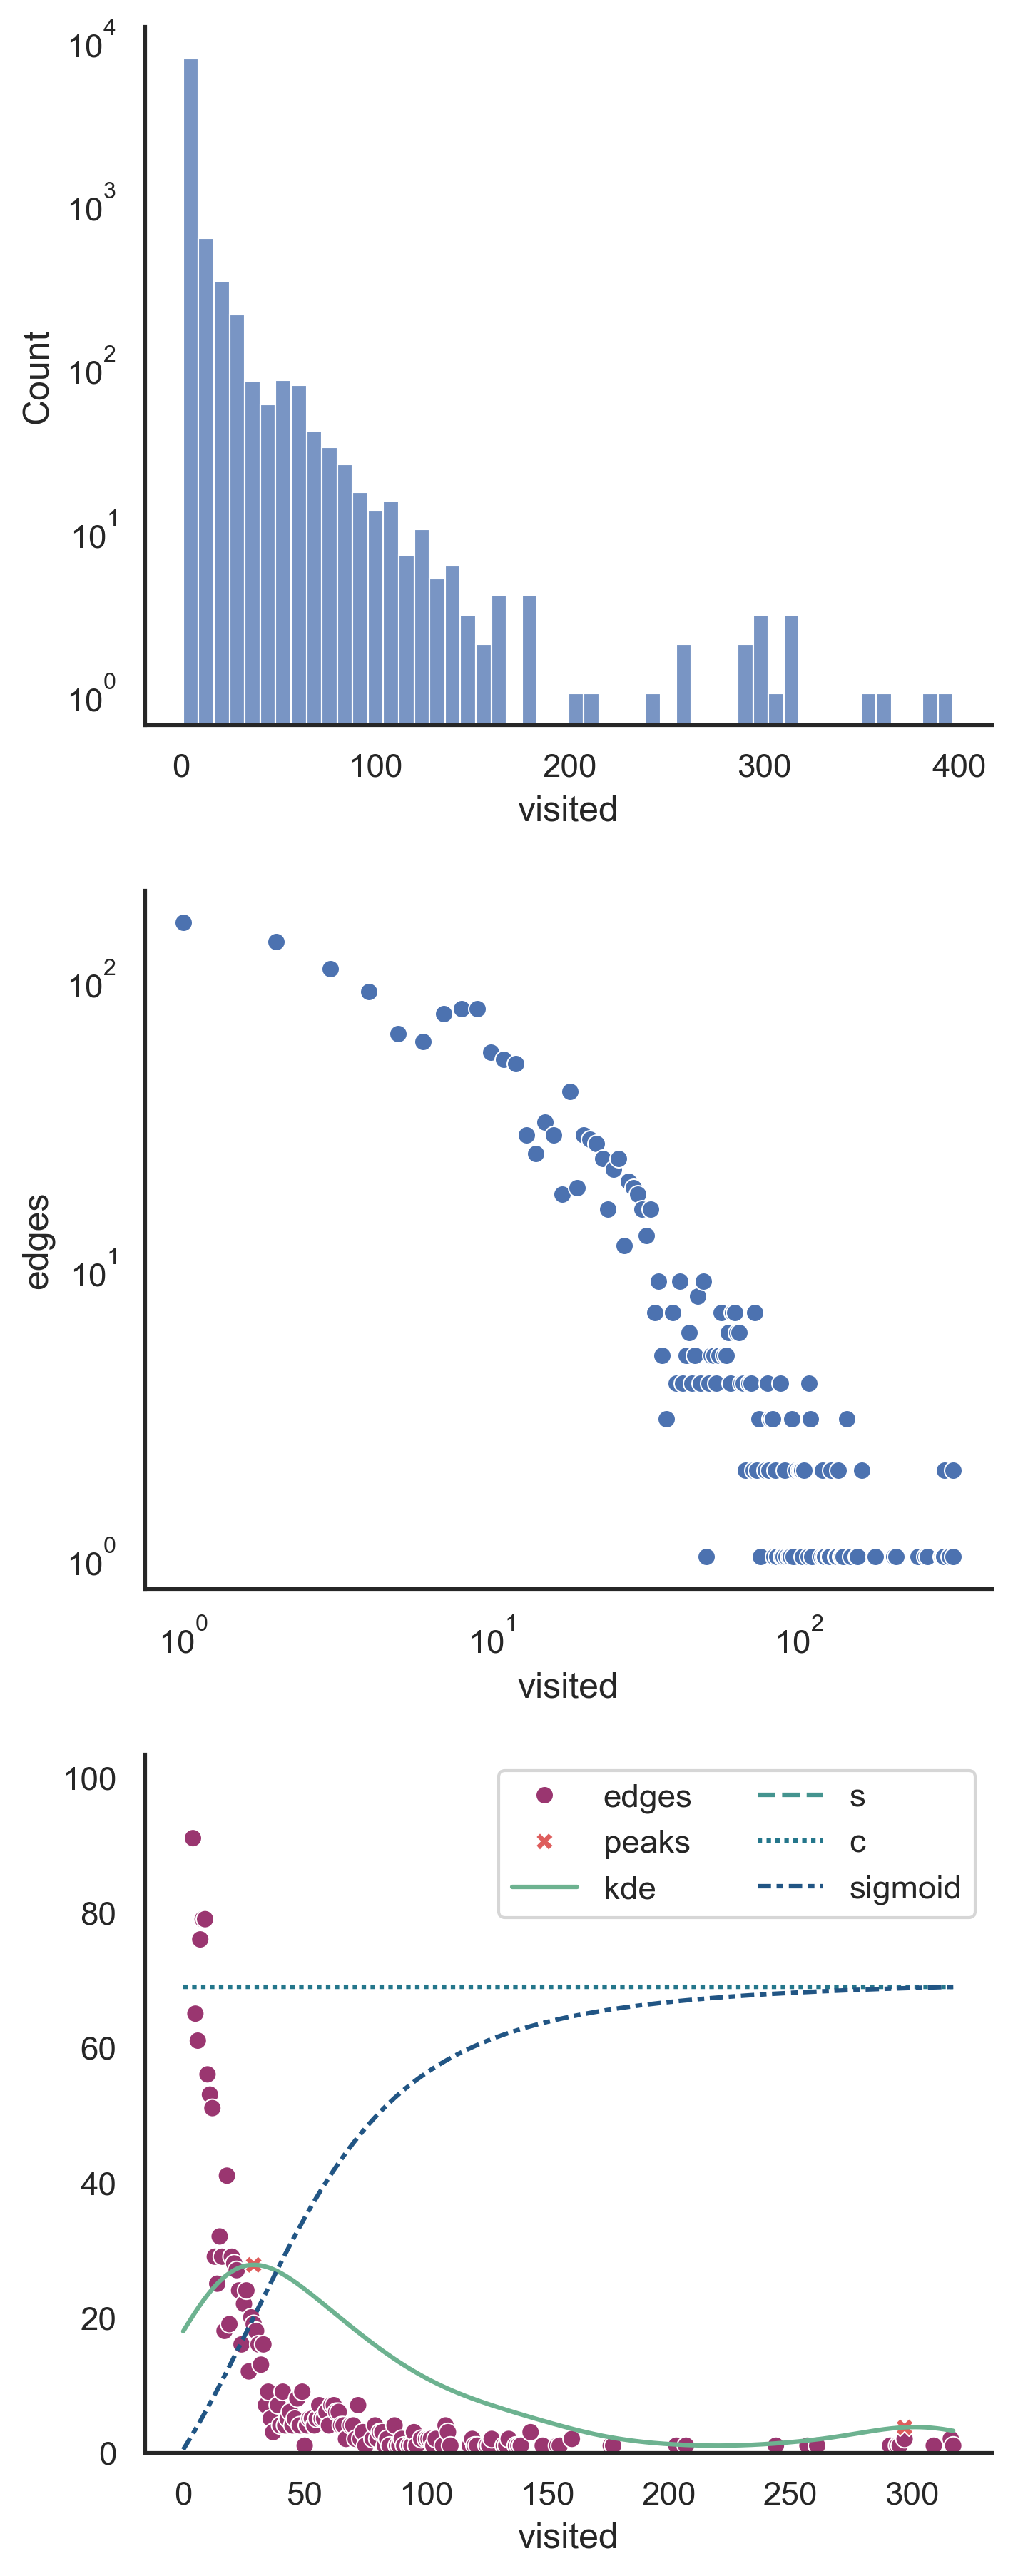

removing interior nodes: Calculating profit and penalty 20% of C and 78% of G have been run. 

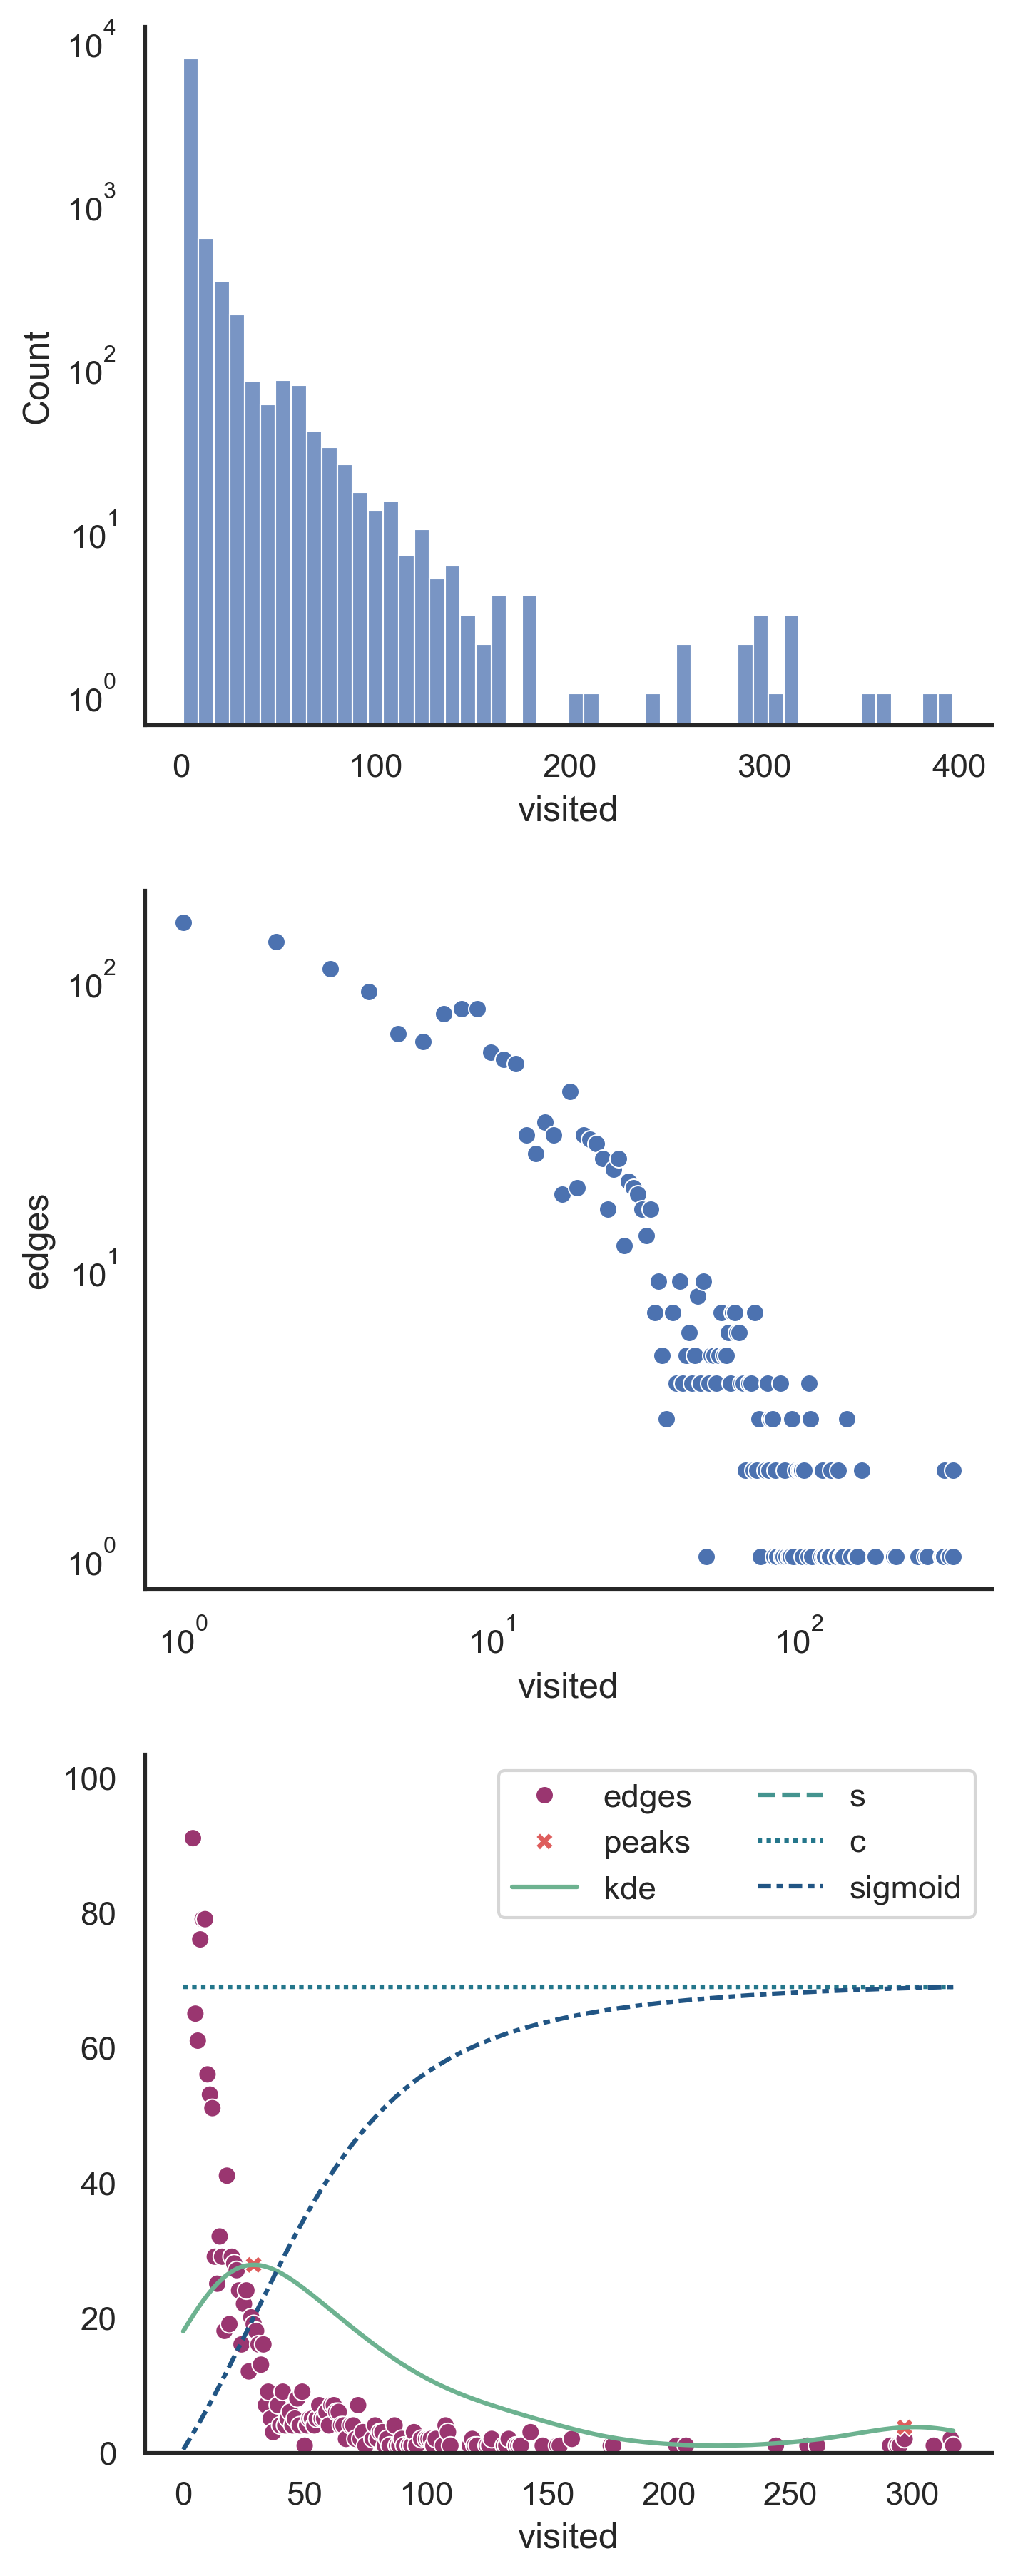

In [50]:
jess_min = InstanceHandler("Sunshine Hills", "jess-min", load_from_files=True)
# jess_min.create_cs_graph()
# jess_min.plot()
# jess_min.create_routes()
# jess_min.create_composite_graph()
# jess_min.plot("C")
# jess_min.add_visited_counts()
# jess_min.plot("heatmap")
# jess_min.create_instances(["base"])
jess_min.plot("profit_base")
jess_min.create_instances("noderem")
jess_min.plot("profit_noderem")

## Process

## runtrack

# Model Formulation

## Description

Let $G(V, A)$ denote a directed graph with vertices $V$ and arcs $A$. Each arc $a \in A$ has an associated profit, $s_{ij}$, historic penalty $q_{ij}$, current penalty, $p_{ij}$, and length, $c_{ij}$. The profit of an arc is derived from the CityStrides data and the penalties are derived from the visited count of that particular arc. Choosing to run an arc will incurr a cost comprising of its profit and penalties. The final route must form a tour, where the solution must start and end at the depot, and must not contain any subtours. The total distance must be within 80%-100% of the user-defined desired run length. The objective is to maximize the total profit incurred by a tour. 


## Mathematical formulation

The decision variables are $x_{ij}, y_{ij}$ and $z_{ij}$, and are defined below: 

\begin{align*}
    x_{ij} = \text{Number of times arc $(i,j)$ is ran}
\end{align*}

\begin{align*}
y_{ij} = 
\begin{cases}
1 & \text{if arc $(i,j)$ is chosen to be ran}  \\
0 & \text{otherwise }
\end{cases}
\end{align*}

\begin{align*}
    z_{ij} = 
    \begin{cases}
    1 & \text{if either arc $(i,j)$ or arc $(j,i)$ is chosen to be ran}  \\
    0 & \text{otherwise }
    \end{cases}
\end{align*}

The variables $x_{ij}$ and $y_{ij}$ are used to define choosing an arc $(i,j)$ to be ran. The variable $z_{ij}$ is used to determine the profit of an arc. The profit of running a particular arc is independent of the direction, ie. running an arc $(i,j)$ from $i$ to $j$ should incur the same profit as $j$ to $i$ and should only be incurred once if both directions are ran. Therefore, the variable $z_{ij}$ ensures that if we run an arc $(i,j)$ at least once in either direction, we incur the profit of the arc. 

The full model formulation is presented below:

\begin{align*}
    \max & \sum_{(i,j)\in A} s_{ij}z_{ij} - q_{ij}y_{ij} -p_{ij}x_{ij} && \tag{1.1}\\
    \text{s.t.} &  \sum\limits_{j \in V\setminus i} x_{ij}  = \sum\limits_{j \in V\setminus i} x_{ji} && \forall i \in V & \tag{1.2}\\
    & z_{ij} \geq y_{ij} && \forall (i,j) \in A, i\leq\ j & \tag{1.3}\\
    & z_{ij} \geq y_{ji} && \forall (i,j) \in A, i\leq j & \tag{1.4}\\
    & y_{ij} + y_{ji} \geq z_{ij} && \forall (i,j) \in A, i\leq j & \tag{1.5}\\
    & \sum\limits_{i \in V\setminus S, j \in S} x_{ij} \geq y_{kl} && \forall S \subset V\setminus \{0\},  \forall(k,l) \in A(S) & \tag{1.6}\\
    & x_{ij} \geq y_{ij} && \forall (i,j) \in A & \tag{1.7}\\
    & y_{ij}\cdot 2 \geq x_{ij} && \forall (i,j) \in A &\tag{1.8} \\
    & \sum\limits_{(i,j) \in A} c_{ij}x_{ij} \leq T_{max} & \tag{1.9}\\
    & \sum\limits_{(i,j) \in A} c_{ij}x_{ij} \geq 0.8\cdot T_{max} & \tag{1.10}\\
    & \sum\limits_{j\in A(0)} y_{0j} \geq 1 & \tag{1.11}\\
    & x_{ij} \in \mathbb{N} && \forall (i,j) \in A & \tag{1.12}\\
    & y_{ij} \in \{0,1\} && \forall (i,j) \in A & \tag{1.13}\\
    & z_{ij} \in \{0,1\} && \forall (i,j) \in A, i<j & \tag{1.14}\\
\end{align*}

The Objective function (1.1) defines the total profit of a run and is accumulated from the profit of running new arcs minus the historic and current penalty from running arcs that have already been ran. Constraint (1.2) is the symmetry constraint which ensure flow conservation at each node. The set of Constraints (1.3-1.5) reflect the bi-conditional relationship between the variables $y_{ij}$ and $z_{ij}$, where the variable $z_{ij}$ must be 1 if either $y_{ij}$ or $y_{ji}$ is 1, and 0 otherwise. Subtours are eliminated by Constraint (1.6), where $S$ denotes any tour that does not contain the depot 0 and therefore must be a subtour. The constraint eliminates these subtours by ensuring that for all edges in the subtour $y \in S$, you must enter the subtour at least once using edges between nodes that are in the subtour, $j \in S$, and the nodes that are not in the subtour, $i \in S$. Constraints (1.7-1.8) reflect the bi-conditional relationship between the variables $x_{ij}$ and $y_{ij}$ where $y_{ij}=1$ if $x_{ij}>=1$ and vice versa. The total length is reflected in the Constraints (1.9-1.10) where the total distance ran must be less than the maximimum $T_{max}$ but more than 80% of $T_{max}$. The second constraint of these two was added to ensure that the final route is still close to our desired run length. Without it, the model can return a short route that maximimizes the profit by not running edges that have been already ran. Finally, Constraint (1.11) ensures that we start at the depot, which is node 0, by forcing the model to leave the depot at least once. 

## Code

In [ ]:
import gurobipy as gp
from gurobipy import GRB
import networkx as nx
import matplotlib.pyplot as plt
import osmnx as ox
from collections import defaultdict

import generate_instances
import pickle
import pandas as pd
import time

In [ ]:
def subtourelim(model, where):
    
    if where == GRB.Callback.MIPNODE:
      

      # Get results
      time=model.cbGet(GRB.Callback.RUNTIME)
      obj=model.cbGet(GRB.Callback.MIPNODE_OBJBST)
      bound=model.cbGet(GRB.Callback.MIPNODE_OBJBND)
      node_count=model.cbGet(GRB.Callback.MIPNODE_NODCNT)
      
      
      model._data.append((time, obj, bound, node_count))

       
    if where == GRB.Callback.MIPSOL:

      solution_x = model.cbGetSolution(model._x)
      solution_y = model.cbGetSolution(model._y)

    ## Subtour elimination
    # Identify visited nodes
      visited_edges = [edge for edge in model._edges if solution_x[edge]>0.05]
      visited_nodes = set()
      for edge in visited_edges:
        i,j = edge
        visited_nodes.update({i,j})

      # Define graph of subtours
      S = nx.Graph()
      for i in visited_nodes:
         for j in visited_nodes:
            if (i,j) in model._edges:
                if i!=j and solution_x[(i,j)] > 0.05:
                    S.add_edge(i,j)

      # Find connected components (subtours)
      components = list(nx.connected_components(S))

      # Add subtour elimination constraints for each disconnected component
      for subtour in components:
        if model._depot in subtour:
          continue

        expr_arc = gp.quicksum(model._x[i,j] for i in subtour for j in subtour if i!=j and (i,j) in model._edges)
        model.cbLazy((expr_arc <= len(subtour) - 1))

def solve_MIP(C, total_length, start_node_no, time_limit):

  C = nx.DiGraph(C)

  # Get visited, profit, and penalty
  visited = {edge: C.edges[edge]['visited'] for edge in C.edges}
  profit = {edge: C.edges[edge]['profit'] for edge in C.edges}
  penalty = {edge: C.edges[edge]['penalty'] for edge in C.edges}

  edges, lengths = gp.multidict({edge:C.edges[edge]['length'] for edge in C.edges })
  nodes = C.nodes
  # node_dict = {i:{j for _, j in edges if _ == i } for i in nodes} # Dictionary of connected nodes, old really slow

  node_dict = defaultdict(set)
  for i,j in edges:
    node_dict[i].add(j)

  # Build model

  m = gp.Model("mp")
  print('building model...')

  # Variables
  print('adding variables...')
  x = m.addVars(edges, name="traversed", vtype=GRB.INTEGER) # number of times arc (i,j) is traversed
  y = m.addVars(edges, name="run", vtype=GRB.BINARY) # arc (i,j) is chosen to be ran, {0,1}

  z = m.addVars({(i,j) for i,j in edges if i< j}, name = 'profitable_route', vtype=GRB.BINARY)

  ## Constraints
  print('adding constraints...')

  # Symmetry Constraint
  symm = m.addConstrs((x.sum(i,'*') == x.sum('*', i) for i in node_dict), name = 'symmetry')

  # Connectivity Constraint (bi-conditional)
  conn1_const = m.addConstrs((x[i,j] >= y[i,j] for i in nodes for j in nodes if i!=j and j in node_dict[i]))
  conn2_const = m.addConstrs((y[i,j]*2 >= x[i,j] for i in nodes for j in nodes if i!=j and j in node_dict[i]))

  # Total Length Constraint
  max_length_const = m.addConstr((x.prod(lengths)<=total_length), name = 'total_length')
  min_length_const = m.addConstr((x.prod(lengths)>=total_length*0.8), name = 'total_length')


  # Start at start node
  start_node = m.addConstrs((y.sum(start_node_no, j)>=1 for j in node_dict[start_node_no]), name='start_node') ## this crashes the model, makes it infeasible

  # Set only one route as profitable

  profit_1 = m.addConstrs((z[i,j] >= y[i,j] for i in nodes for j in nodes if i<=j and (i,j) in edges))
  profit_2 = m.addConstrs((z[i,j] >= y[j,i] for i in nodes for j in nodes if i<=j and (i,j) in edges))
  profit_3 = m.addConstrs((y[i,j] + y[j,i] >= z[i,j] for i in nodes for j in nodes if i<=j and (i,j) in edges))

  print('add objective function...')
  m.setObjective(z.prod(profit)-y.prod(penalty)-x.prod(visited), GRB.MAXIMIZE)

  # Set-up lazy constraints and call variables
  m.Params.LazyConstraints = 1
  m._x = x
  m._y = y
  m._z = z
  m._edges = edges
  m._N = nodes
  m._data = []
  m._depot = start_node_no
  m.setParam('TimeLimit', time_limit)
  m.setParam('LogtoConsole', 0)
  m.setParam('LogFile', f'baseline_{instance}_{total_length}.log')


  print('start solving model...')
  m.optimize(subtourelim)

  ## Recording solution data
  # Add last solution data
  node_count=m.NodeCount
  obj=m.ObjVal
  bound=m.ObjBound
  time=m.Runtime
  m._data.append((time, obj, bound, node_count))

  # Record results
  with open(log_filename + '.csv', "w") as f:
    for sol_data in m._data:
      time, obj, bound, node_count = sol_data

      f.write("{}, {}, {}, {}\n".format(time, obj, bound, node_count))

  # If model found a feasible solution in the time limit
  if m.solCount > 0:

    # Draw final graph
    F = nx.DiGraph()

    for i in nodes:
      for j in nodes:
          if (i,j) in edges:
            if x[(i,j)].x >= 0.05:
                F.add_edge(i,j, visited=float(x[(i,j)].x))

    # pos = nx.spring_layout(F)
    # plt.figure()
    # nx.draw(F, pos, with_labels=True, node_color='lightblue', edge_color='gray', arrows=True)
    # plt.title("Optimal Run")
    # plt.show()

    # Create final graph solution
    print("saving graphs to file", end=" ", flush=True)
    
    log_filepath = "final_test/"

    with open(
        log_filepath+"sol_graph_" + instance + "_" + str(total_length) + ".pkl", "wb",
    ) as file:
        pickle.dump(F, file, pickle.HIGHEST_PROTOCOL)

  print("complete!")


# Parameters
total_length_lst =[5000, 10000, 15000]
instance_lst = ["instance-jess-min","instance-jess","instance-jin"]

time_limit=1800

for instance in instance_lst:
  for total_length in total_length_lst:
    
    if 'jess' in instance:
       start_node_no = 6813225352
    
    if 'jin' in instance:
       start_node_no = 394502562

    log_filepath = "final_test/"
    log_filename = log_filepath + instance + '_' + str(total_length)

    print("reading instance file...")

    C  = pd.read_pickle(instance +'.pkl')

    C = ox.truncate.truncate_graph_dist(C,start_node_no,total_length)

    # Run experiments
    print('running experiment with ' + str(total_length) + ' total_length')
    solve_MIP(C, total_length, start_node_no, time_limit)

# Instances

## Graph sizes

`instance-jess-min` has 3015 nodes, 6596 edges, and 67% of G has been run

`instance-jess` has 84,756 nodes, 187,294 edges, and 21% of G has been run

`instance-jin` has 385,229 nodes, 867,782 edges, and 1% of G has been run

## Run lengths

* `5K`
* `10K`
* `15K`

# Results

The lower bounds and objective values from solving each instance is presented below:

<center><img src='images/baseline-jess-min-5.png'/></center>
<center><img src='images/baseline-jess-min-10.png'/></center>
<center><img src='images/baseline-jess-min-15.png'/></center>

Results from full neighborhood

<center><img src='images/baseline-jess-5.png'/></center>
<center><img src='images/baseline-jess-10.png'/></center>
<center><img src='images/baseline-jess-15.png'/></center>


table mip gap, node count, found feasible solution? add jin add routes beef up discussion

## Discussion

For 10km, it could not find a feasible solution within the given time. 

# Improvements

## Interior node removal

jess: add code

## Alternative attempts:

jin: add the 3 models, and results to back it up jess: plz talk about them

### Penalty constraint

### Lower bound

### Branching

# Conclusion

jess and jin
- improvements didn't imrpove, but we're happy wiht some good routes at the end. at least they're feasible and reasonable. jess can run those, if jess wants to, do small neighborhood of toronto since we saw it work for delta

Future work
- undirected, try a different formulation, more tractable

# Declaration of Contribution

one sentence

# References

<a id="citystrides"></a>Chevalier, J. CityStrides. https://citystrides.com/

<a id="pytrack"></a>Tortora, M., Cordelli, E., & Soda, P. (2022). PyTrack: a Map-Matching-based Python Toolbox for Vehicle Trajectory Reconstruction. IEEE Access, 10, 112713–112720. https://doi.org/10.1109/ACCESS.2022.3216565

<a id=wandrer></a>Wandrer. https://wandrer.earth/